데이터 출처: https://www.kaggle.com/datasets/tatheerabbas/psychological-manipulation-conversations-dataset

위의 LLM을 통하여 인위적으로 생성된 데이터로 텍스트 속에서 심리조작기법을 분석하며 그 조작기법에 따른 사람의 감정 영향을 나타낸 데이터입니다.

In [ ]:
import pandas as pd



file_path = r"/content/drive/MyDrive/Colab Notebooks/manipulational_conversation.jsonl"

# jsonl 파일 불러오기
df = pd.read_json(file_path, lines=True)

# 데이터 확인
print("데이터의 크기:", df.shape)
display(df.head())


데이터의 크기: (10000, 21)


,conversation_id,manipulation_type,is_manipulation,context_type,conversation_length,manipulation_intensity,messages,target_confusion,guilt_level,fear_level,...,self_doubt,target_extraversion,target_emotional_resilience,target_assertiveness,target_attachment_style,avg_response_delay_seconds,escalation_pattern,word_count_total,question_count,denial_count
0,conv_00000,guilt_tripping,True,friend,3,0.705,"[{'speaker': 'A', 'text': 'Remember when I hel...",0.136,0.797,0.224,...,0.306,0.375,0.101,0.222,disorganized,162,sudden,28,1,0
1,conv_00001,charm_flattery,True,friend,6,0.530,"[{'speaker': 'A', 'text': 'I don't tell just a...",0.219,0.306,0.041,...,0.459,0.366,0.380,0.342,secure,93,gradual,51,2,5
2,conv_00002,direct_coercion,True,family,7,0.651,"[{'speaker': 'A', 'text': 'Just do it', 'senti...",0.253,0.166,0.760,...,0.335,0.259,0.064,0.201,anxious,58,gradual,37,1,6
3,conv_00003,gaslighting,True,friend,6,0.673,"[{'speaker': 'A', 'text': 'You're being way to...",0.702,0.123,0.194,...,0.799,0.987,0.168,0.422,disorganized,342,cyclical,41,0,5
4,conv_00004,guilt_tripping,True,friend,4,0.331,"[{'speaker': 'A', 'text': 'Go ahead. Have fun....",0.173,0.666,0.126,...,0.355,0.120,0.331,0.787,secure,299,cyclical,25,1,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   conversation_id              10000 non-null  object 
 1   manipulation_type            10000 non-null  object 
 2   is_manipulation              10000 non-null  bool   
 3   context_type                 10000 non-null  object 
 4   conversation_length          10000 non-null  int64  
 5   manipulation_intensity       10000 non-null  float64
 6   messages                     10000 non-null  object 
 7   target_confusion             10000 non-null  float64
 8   guilt_level                  10000 non-null  float64
 9   fear_level                   10000 non-null  float64
 10  anxiety_level                10000 non-null  float64
 11  self_doubt                   10000 non-null  float64
 12  target_extraversion          10000 non-null  float64
 13  target_emotional_

결측치가 없다

**[기초통계 확인]**

In [ ]:
display(df.describe())

,conversation_length,manipulation_intensity,target_confusion,guilt_level,fear_level,anxiety_level,self_doubt,target_extraversion,target_emotional_resilience,target_assertiveness,avg_response_delay_seconds,word_count_total,question_count,denial_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.502300,0.517148,0.344116,0.321732,0.245987,0.438082,0.392572,0.502461,0.303966,0.328283,195.177200,37.166400,1.04590,3.383000
std,1.709177,0.294557,0.235967,0.231932,0.262769,0.253414,0.234436,0.286287,0.192512,0.209750,154.763492,11.492707,0.96555,2.290161
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,18.000000,4.000000,0.00000,0.000000
25%,4.000000,0.335000,0.146000,0.156000,0.063000,0.217000,0.205000,0.256000,0.160000,0.170000,73.000000,28.000000,0.00000,2.000000
50%,6.000000,0.561000,0.308000,0.280000,0.162500,0.439000,0.395500,0.507000,0.268000,0.288000,122.000000,37.000000,1.00000,3.000000
75%,7.000000,0.747000,0.526000,0.405000,0.300000,0.659000,0.528000,0.748000,0.408000,0.442000,288.000000,46.000000,2.00000,5.000000
max,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,599.000000,67.000000,5.00000,12.000000


In [ ]:
print(df['manipulation_type'].unique())
print(df['target_attachment_style'].unique())

['guilt_tripping' 'charm_flattery' 'direct_coercion' 'gaslighting'
 'love_bombing' 'neutral' 'passive_aggressive']
['disorganized' 'secure' 'anxious' 'avoidant']


In [ ]:
print(df['manipulation_type'].value_counts())
print(df['target_attachment_style'].value_counts())

manipulation_type
neutral               1600
charm_flattery        1400
guilt_tripping        1400
direct_coercion       1400
gaslighting           1400
love_bombing          1400
passive_aggressive    1400
Name: count, dtype: int64
target_attachment_style
anxious         4209
avoidant        2412
secure          1988
disorganized    1391
Name: count, dtype: int64


 다양한 심리 조작 기법(manipulation_type)과 내면적 성향인 애착 유형(target_attachment_style)이 타겟의 심리적 지표(불안, 혼란, 자기 의심 등)에 미치는 영향을 분석하는 것에 목적을 두었습니다. 특히 각 지표 간의 상관관계를 통해 조작기법이 어떻게 심리적 연쇄 반응을 일으키는지 파악하고자 합니다.

## 1️⃣ TASK 1: 데이터 전처리

### 1.1 결측치 처리 (Missing Value Handling)

이전 `df.info()` 결과에서 모든 컬럼의 Non-Null Count가 10000으로 나타나 데이터셋에 결측치가 없음을 확인했습니다. 따라서 별도의 결측치 처리 과정은 필요하지 않습니다.

### 1.2 이상치 처리 (Outlier Handling)

`df.describe()` 결과 및 데이터 분포 시각화를 통해 `conversation_length`, `avg_response_delay_seconds`, `word_count_total`, `question_count`, `denial_count`와 같은 일부 수치형변수의 해당 이상치들을 Q1 - 1.5*IQR 또는 Q3 + 1.5*IQR 값으로 상한/하한을 설정하는 capping 방식으로 처리. 이는 데이터의 극단적인 값들이 모델 성능에 미치는 부정적인 영향을 줄이면서도 데이터 손실을 최소화하기 위함.

In [ ]:
# 한글 폰트 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시를 완전히 재설정하기 위해 matplotlib를 다시 임포트하기 전 설정
# 일반적으로 런타임 재시작이 가장 확실하지만, 코드 상으로 시도할 수 있는 방법
fm._load_fontmanager(try_read_cache=False)

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다. 플로팅 셀을 다시 실행하여 확인해주세요.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

한글 폰트 설정이 완료되었습니다. 플로팅 셀을 다시 실행하여 확인해주세요.


### EDA - 변수 간 관계 분석 및 유의미한 시각화

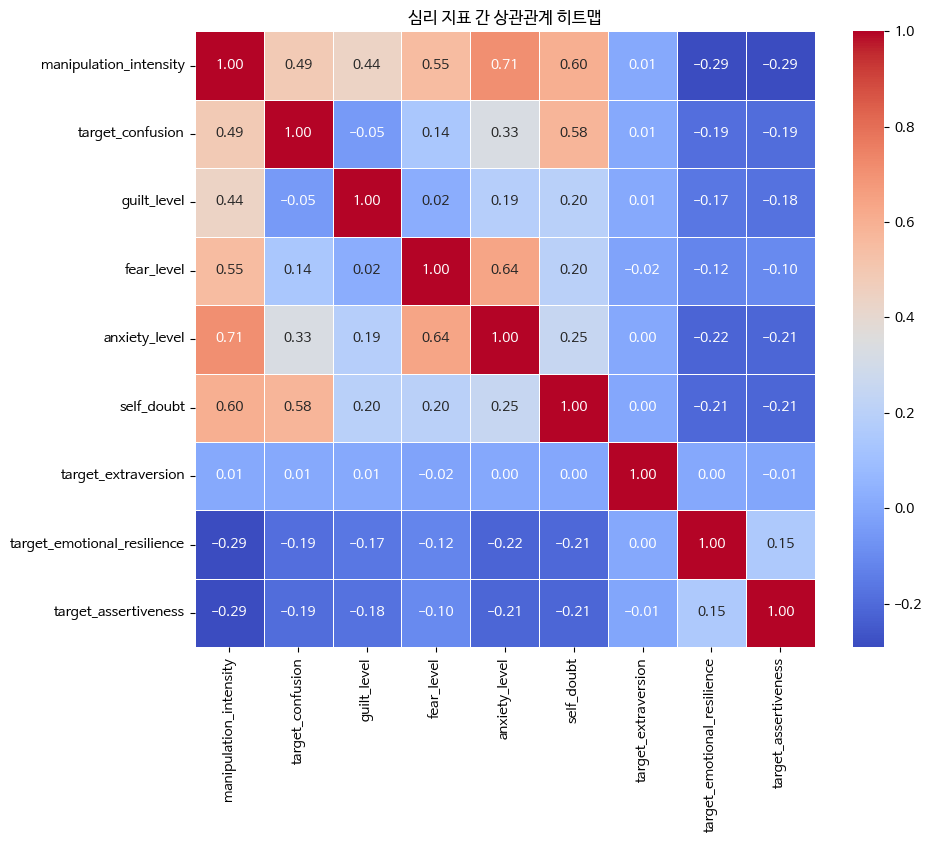

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 상관관계 분석을 위한 숫자형 심리 지표 선택
psych_features = [
    'manipulation_intensity',
    'target_confusion',
    'guilt_level',
    'fear_level',
    'anxiety_level',
    'self_doubt',
    'target_extraversion',
    'target_emotional_resilience',
    'target_assertiveness'
]

corr_matrix = df[psych_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('심리 지표 간 상관관계 히트맵')
plt.show()

/tmp/ipykernel_39390/3711512250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='manipulation_type', y='manipulation_intensity', data=df, palette='viridis')


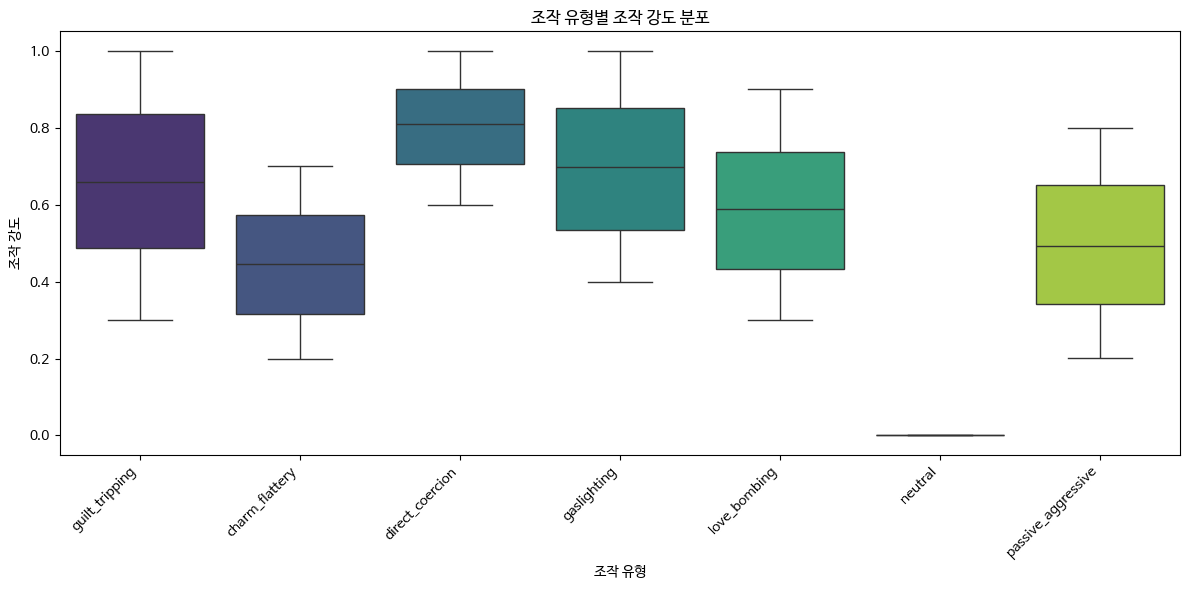

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='manipulation_type', y='manipulation_intensity', data=df, palette='viridis')
plt.title('조작 유형별 조작 강도 분포')
plt.xlabel('조작 유형')
plt.ylabel('조작 강도')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_39390/889727881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_attachment_style', y='target_confusion', data=df, palette='plasma')


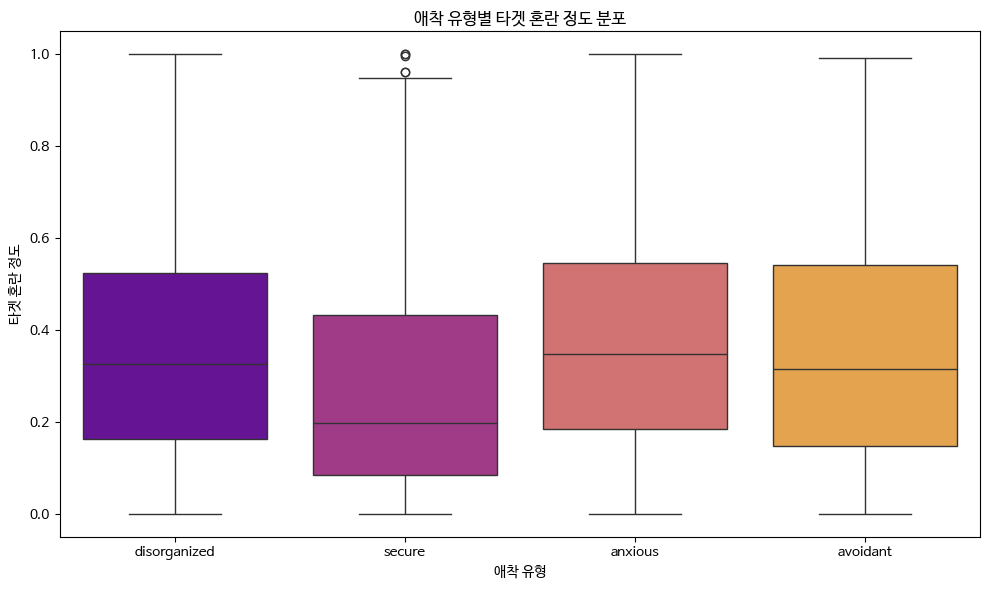

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target_attachment_style', y='target_confusion', data=df, palette='plasma')
plt.title('애착 유형별 타겟 혼란 정도 분포')
plt.xlabel('애착 유형')
plt.ylabel('타겟 혼란 정도')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# 이상치 처리를 적용할 수치형 컬럼 리스트
outlier_cols = [
    'conversation_length',
    'avg_response_delay_seconds',
    'word_count_total',
    'question_count',
    'denial_count'
]

def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 이상치를 하한 또는 상한 값으로 대체
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# 각 컬럼에 이상치 처리 적용
for col in outlier_cols:
    df = cap_outliers_iqr(df.copy(), col)
    print(f"'{col}' 컬럼의 이상치 처리가 완료되었습니다.")

print("\n이상치 처리 후 주요 통계량 확인:")
display(df[outlier_cols].describe())

'conversation_length' 컬럼의 이상치 처리가 완료되었습니다.
'avg_response_delay_seconds' 컬럼의 이상치 처리가 완료되었습니다.
'word_count_total' 컬럼의 이상치 처리가 완료되었습니다.
'question_count' 컬럼의 이상치 처리가 완료되었습니다.
'denial_count' 컬럼의 이상치 처리가 완료되었습니다.

이상치 처리 후 주요 통계량 확인:


,conversation_length,avg_response_delay_seconds,word_count_total,question_count,denial_count
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000
mean,5.502300,195.177200,37.166400,1.04590,3.37800
std,1.709177,154.763492,11.492707,0.96555,2.27531
min,3.000000,18.000000,4.000000,0.00000,0.00000
25%,4.000000,73.000000,28.000000,0.00000,2.00000
50%,6.000000,122.000000,37.000000,1.00000,3.00000
75%,7.000000,288.000000,46.000000,2.00000,5.00000
max,8.000000,599.000000,67.000000,5.00000,9.50000


## 2️⃣ TASK 2: 피쳐 엔지니어링 (Feature Engineering)

기존 데이터셋의 변수들을 활용하여 머신러닝 모델의 예측 성능을 높일 수 있는 새로운 파생 변수 2가지를 생성하겠습니다.

### 2.1 심리적 고통 지수 (`psychological_distress_score`)

`target_confusion`, `guilt_level`, `fear_level`, `anxiety_level`, `self_doubt`와 같은 부정적인 심리 지표들을 조합하여 **`psychological_distress_score`**라는 통합 지표를 생성합니다. 이는 대상이 겪는 전반적인 심리적 고통의 수준을 나타내며, 조작 유형이 개인의 심리 상태에 미치는 복합적인 영향을 더 잘 포착할 수 있습니다. 각 지표는 0과 1 사이의 값으로 이미 정규화되어 있으므로, 단순 평균을 통해 통합 지표를 생성합니다.

### 2.2 조작 영향 비율 (`manipulation_impact_ratio`)

`manipulation_intensity`와 `target_emotional_resilience`, `target_assertiveness`를 결합하여 **`manipulation_impact_ratio`**를 생성합니다. 이 지표는 주어진 조작 강도에 대해 대상의 심리적 회복탄력성과 자기주장성이 얼마나 잘 작동하는지를 나타냅니다. 조작 강도가 높더라도 회복탄력성이 높으면 영향은 적을 것이고, 회복탄력성이 낮으면 영향이 클 것입니다. `target_emotional_resilience`와 `target_assertiveness`는 0과 1 사이의 값이므로, 분모가 0이 되는 것을 방지하기 위해 작은 상수(0.01)를 더합니다.

In [ ]:
# 1. 심리적 고통 지수 (psychological_distress_score) 생성
# 부정적 심리 지표들의 평균을 사용
df['psychological_distress_score'] = df[[
    'target_confusion',
    'guilt_level',
    'fear_level',
    'anxiety_level',
    'self_doubt'
]].mean(axis=1)

# 2. 조작 영향 비율 (manipulation_impact_ratio) 생성
# 조작 강도를 회복탄력성과 자기주장성의 합으로 나눔 (0으로 나누는 것을 방지)
df['manipulation_impact_ratio'] = df['manipulation_intensity'] / \
                                (df['target_emotional_resilience'] + df['target_assertiveness'] + 0.01)

# 새로운 파생 변수 확인
print("\n새로운 파생 변수 생성 후 DataFrame head:")
display(df[['manipulation_intensity', 'target_emotional_resilience', 'target_assertiveness', 'psychological_distress_score', 'manipulation_impact_ratio']].head())


새로운 파생 변수 생성 후 DataFrame head:


,manipulation_intensity,target_emotional_resilience,target_assertiveness,psychological_distress_score,manipulation_impact_ratio
0,0.705,0.101,0.222,0.3122,2.117117
1,0.530,0.380,0.342,0.2320,0.724044
2,0.651,0.064,0.201,0.4494,2.367273
3,0.673,0.168,0.422,0.4954,1.121667
4,0.331,0.331,0.787,0.3514,0.293440


### 모델 구현 단계

1.  **데이터 준비**: 예측에 사용할 특성(Features, X)과 목표 변수(Target, y)를 정의합니다.
2.  **데이터 전처리**: 범주형 데이터를 숫자로 변환(인코딩)하고, 데이터를 훈련 세트와 테스트 세트로 나눕니다.
3.  **모델 선택 및 훈련**: 문제에 적합한 머신러닝 모델을 선택하고 훈련 데이터로 학습시킵니다.
4.  **모델 평가**: 훈련된 모델의 성능을 평가하고, 필요하다면 개선 방안을 모색합니다.

### 1. 데이터 준비: 특성(X)과 목표 변수(y) 정의

이전 분석 목적에 따라, 심리적 지표들을 특성으로 사용하여 `manipulation_type`을 예측하는 모델을 구현해 보겠습니다.

`manipulation_type`은 범주형 데이터이므로, 머신러닝 모델이 이해할 수 있도록 숫자로 변환해야 합니다. `LabelEncoder`를 사용하여 변환하겠습니다.

### 테스트 데이터에 '대응 가이드라인' 적용 예시

훈련된 모델의 입력 데이터인 `manipulation_intensity`를 활용하여 `get_action_plan` 함수가 어떻게 동작하는지 테스트 세트의 일부 데이터를 통해 확인해 보겠습니다.

In [ ]:
# 테스트 세트에서 manipulation_intensity 샘플 추출
# X_test_attachment는 이미 스케일링되지 않은 원본 값을 포함하고 있습니다.
# 몇 개의 샘플을 무작위로 선택하여 시연합니다.

sample_indices = X_test_attachment.sample(5, random_state=42).index
sample_data = X_test_attachment.loc[sample_indices]

print("--- 테스트 샘플에 대한 대응 가이드라인 ---")
for i, (index, row) in enumerate(sample_data.iterrows()):
    intensity = row['manipulation_intensity']
    plan = get_action_plan(intensity)
    print(f"\n[샘플 {i+1} - 원본 인덱스: {index}]")
    print(f"조작 강도: {intensity:.2f}")
    print(f"위험 수준: {plan['level']}")
    print(f"액션 플랜: {plan['message']}")

--- 테스트 샘플에 대한 대응 가이드라인 ---

[샘플 1 - 원본 인덱스: 151]
조작 강도: 0.60
위험 수준: 경고
액션 플랜: 상대방의 조작 강도가 높습니다. 대화를 잠시 중단하거나 전문가와 상담을 고려해 보세요. 필요한 경우 대화 기록을 보존하는 것이 좋습니다.

[샘플 2 - 원본 인덱스: 7936]
조작 강도: 0.97
위험 수준: 차단 권고
액션 플랜: 매우 높은 수준의 심리적 조작이 진행 중입니다. 당신의 정신 건강을 위해 즉시 상대방과의 소통을 중단하고 필요한 경우 주변에 도움을 요청하거나 전문 기관의 지원을 받는 것을 강력히 권고합니다.

[샘플 3 - 원본 인덱스: 6284]
조작 강도: 0.68
위험 수준: 경고
액션 플랜: 상대방의 조작 강도가 높습니다. 대화를 잠시 중단하거나 전문가와 상담을 고려해 보세요. 필요한 경우 대화 기록을 보존하는 것이 좋습니다.

[샘플 4 - 원본 인덱스: 2730]
조작 강도: 0.84
위험 수준: 차단 권고
액션 플랜: 매우 높은 수준의 심리적 조작이 진행 중입니다. 당신의 정신 건강을 위해 즉시 상대방과의 소통을 중단하고 필요한 경우 주변에 도움을 요청하거나 전문 기관의 지원을 받는 것을 강력히 권고합니다.

[샘플 5 - 원본 인덱스: 3178]
조작 강도: 0.92
위험 수준: 차단 권고
액션 플랜: 매우 높은 수준의 심리적 조작이 진행 중입니다. 당신의 정신 건강을 위해 즉시 상대방과의 소통을 중단하고 필요한 경우 주변에 도움을 요청하거나 전문 기관의 지원을 받는 것을 강력히 권고합니다.


### 새로운 모델 구현: 애착 유형(target_attachment_style) 예측

### 1. 데이터 준비: 특성(X_attachment)과 목표 변수(y_attachment) 정의

이전 분석 목적에 따라, 심리적 지표들을 특성으로 사용하여 `target_attachment_style`을 예측하는 모델을 구현해 보겠습니다.

`target_attachment_style`은 범주형 데이터이므로, 머신러닝 모델이 이해할 수 있도록 숫자로 변환해야 합니다. `LabelEncoder`를 사용하여 변환하겠습니다.

In [ ]:
# 사용할 변수 (특성 - X)
# 'manipulation_type'을 제외한 심리적 지표들을 사용합니다.
features_attachment = [
    'manipulation_intensity',
    'target_confusion',
    'guilt_level',
    'fear_level',
    'anxiety_level',
    'self_doubt',
    'target_extraversion',
    'target_emotional_resilience',
    'target_assertiveness'
]

X_attachment = df[features_attachment]

# 목표 변수 (y): 'target_attachment_style'
y_attachment = df['target_attachment_style']

# 'target_attachment_style'을 숫자로 인코딩
le_attachment = LabelEncoder()
y_encoded_attachment = le_attachment.fit_transform(y_attachment)

print("특성(X_attachment) 데이터 형태:", X_attachment.shape)
print("목표 변수(y_attachment) 인코딩 후 형태:", y_encoded_attachment.shape)
print("인코딩된 'target_attachment_style' 레이블:", le_attachment.classes_)

특성(X_attachment) 데이터 형태: (10000, 9)
목표 변수(y_attachment) 인코딩 후 형태: (10000,)
인코딩된 'target_attachment_style' 레이블: ['anxious' 'avoidant' 'disorganized' 'secure']


### 2. 데이터 전처리: 훈련/테스트 세트 분리 및 스케일링

데이터를 훈련 세트와 테스트 세트로 나누고, `StandardScaler`를 사용하여 특성들을 표준화(스케일링)합니다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터를 훈련 세트와 테스트 세트로 분리
X_train_attachment, X_test_attachment, y_train_attachment, y_test_attachment = train_test_split(
    X_attachment, y_encoded_attachment,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded_attachment
)

print("훈련 세트 X_attachment 형태:", X_train_attachment.shape)
print("테스트 세트 X_attachment 형태:", X_test_attachment.shape)
print("훈련 세트 y_attachment 형태:", y_train_attachment.shape)
print("테스트 세트 y_attachment 형태:", y_test_attachment.shape)

# 특성 스케일링 (StandardScaler)
scaler_attachment = StandardScaler()
X_train_scaled_attachment = scaler_attachment.fit_transform(X_train_attachment)
X_test_scaled_attachment = scaler_attachment.transform(X_test_attachment)

print("스케일링된 훈련 세트 X_attachment 형태:", X_train_scaled_attachment.shape)
print("스케일링된 테스트 세트 X_attachment 형태:", X_test_scaled_attachment.shape)

훈련 세트 X_attachment 형태: (8000, 9)
테스트 세트 X_attachment 형태: (2000, 9)
훈련 세트 y_attachment 형태: (8000,)
테스트 세트 y_attachment 형태: (2000,)
스케일링된 훈련 세트 X_attachment 형태: (8000, 9)
스케일링된 테스트 세트 X_attachment 형태: (2000, 9)


### 3. 모델 선택 및 훈련

**로지스틱 회귀(Logistic Regression)**와 **랜덤 포레스트(Random Forest Classifier)** 모델을 훈련

### 4. 모델 평가

훈련된 로지스틱 회귀 모델과 랜덤 포레스트 분류기를 사용하여 테스트 세트에 대한 예측을 수행하고, 각 모델의 성능을 평가합니다.

### 대응 가이드라인 구현: 위험도 알림 및 액션 플랜

In [ ]:
def get_action_plan(manipulation_intensity):
    """
    조작 강도(manipulation_intensity)에 따라 실질적인 액션 플랜을 제시합니다.
    """
    if manipulation_intensity >= 0.8:
        return {
            "level": "차단 권고",
            "message": "매우 높은 수준의 심리적 조작이 진행 중입니다. 당신의 정신 건강을 위해 즉시 상대방과의 소통을 중단하고 필요한 경우 주변에 도움을 요청하거나 전문 기관의 지원을 받는 것을 강력히 권고합니다."
        }
    elif manipulation_intensity >= 0.6:
        return {
            "level": "경고",
            "message": "상대방의 조작 강도가 높습니다. 대화를 잠시 중단하거나 전문가와 상담을 고려해 보세요. 필요한 경우 대화 기록을 보존하는 것이 좋습니다."
        }
    elif manipulation_intensity >= 0.3:
        return {
            "level": "주의",
            "message": "상대방이 미묘하게 당신의 감정을 조작하려는 시도가 감지됩니다. 대화 내용을 객관적으로 되짚어보고 감정적으로 휩쓸리지 않도록 주의하세요."
        }
    else:
        return {
            "level": "안전",
            "message": "현재 심리적 조작 강도는 낮은 수준입니다. 안정적인 대화가 진행 중입니다."
        }

# 예시 사용법:
# 실제 예측된 manipulation_intensity 값을 사용하여 액션 플랜을 얻을 수 있습니다.

# 예시 1: 높은 조작 강도
intensity1 = 0.92
plan1 = get_action_plan(intensity1)
print(f"조작 강도: {intensity1:.2f}\n위험 수준: {plan1['level']}\n액션 플랜: {plan1['message']}\n")

# 예시 2: 중간 조작 강도
intensity2 = 0.65
plan2 = get_action_plan(intensity2)
print(f"조작 강도: {intensity2:.2f}\n위험 수준: {plan2['level']}\n액션 플랜: {plan2['message']}\n")

# 예시 3: 낮은 조작 강도
intensity3 = 0.40
plan3 = get_action_plan(intensity3)
print(f"조작 강도: {intensity3:.2f}\n위험 수준: {plan3['level']}\n액션 플랜: {plan3['message']}\n")

# 예시 4: 조작 강도 매우 낮음
intensity4 = 0.15
plan4 = get_action_plan(intensity4)
print(f"조작 강도: {intensity4:.2f}\n위험 수준: {plan4['level']}\n액션 플랜: {plan4['message']}\n")

조작 강도: 0.92
위험 수준: 차단 권고
액션 플랜: 매우 높은 수준의 심리적 조작이 진행 중입니다. 당신의 정신 건강을 위해 즉시 상대방과의 소통을 중단하고 필요한 경우 주변에 도움을 요청하거나 전문 기관의 지원을 받는 것을 강력히 권고합니다.

조작 강도: 0.65
위험 수준: 경고
액션 플랜: 상대방의 조작 강도가 높습니다. 대화를 잠시 중단하거나 전문가와 상담을 고려해 보세요. 필요한 경우 대화 기록을 보존하는 것이 좋습니다.

조작 강도: 0.40
위험 수준: 주의
액션 플랜: 상대방이 미묘하게 당신의 감정을 조작하려는 시도가 감지됩니다. 대화 내용을 객관적으로 되짚어보고 감정적으로 휩쓸리지 않도록 주의하세요.

조작 강도: 0.15
위험 수준: 안전
액션 플랜: 현재 심리적 조작 강도는 낮은 수준입니다. 안정적인 대화가 진행 중입니다.



## 1️⃣ TASK 1 — 모델링 (Modeling)

### 진행 방법 및 모델 학습 과정 정리

**문제 유형 정의:**
`target_attachment_style` 예측은 주어진 심리 지표들을 바탕으로 대상의 애착 유형 4가지('anxious', 'avoidant', 'disorganized', 'secure') 중 하나를 분류하는 **`Classification (분류)`** 문제입니다.

**모델 선택:**
분류 문제에 적합한 모델로 **`Logistic Regression`**과 **`Random Forest Classifier`**를 선택했습니다. 이 두 모델은 각각 선형 분류 모델과 앙상블 기반 비선형 분류 모델로서, 다양한 분류 문제에서 준수한 성능을 보여주며 모델 비교에 용이합니다.

*   **로지스틱 회귀 (Logistic Regression):** 선형 모델로, 각 특성이 타겟 클래스에 미치는 영향(계수)을 비교적 명확하게 해석할 수 있습니다. 계산 비용이 낮고 빠르게 훈련됩니다.
*   **랜덤 포레스트 (Random Forest):** 여러 결정 트리를 조합하여 예측하는 앙상블 모델입니다. 과적합에 강하며 복잡한 비선형 관계를 잘 학습합니다. 특성 중요도(Feature Importance)를 제공하여 모델 해석에 도움을 줍니다.

**모델 학습 과정:**

1.  **`Train / Test Split 수행`:** `X_attachment` (특성)와 `y_encoded_attachment` (인코딩된 목표 변수)를 각각 훈련 세트(80%)와 테스트 세트(20%)로 분리했습니다. 이때 `stratify=y_encoded_attachment` 옵션을 사용하여 목표 변수의 클래스 비율을 훈련 세트와 테스트 세트에서 동일하게 유지하여 데이터 불균형 문제를 완화했습니다. (`cfb679d7` 셀에서 수행)
2.  **`특성 스케일링`:** `StandardScaler`를 사용하여 모든 수치형 특성들을 표준화했습니다. 이는 특성 값의 범위 차이로 인해 모델 학습이 특정 특성에 편향되는 것을 방지하고, 특히 로지스틱 회귀와 같이 거리 기반 계산에 영향을 받는 모델의 성능을 향상시킵니다. (`cfb679d7` 셀에서 수행)
3.  **`모델 학습`:** 스케일링된 훈련 데이터 (`X_train_scaled_attachment`, `y_train_attachment`)를 사용하여 두 모델을 학습시켰습니다. (`27ab2c6c` 셀에서 수행)

    *   **로지스틱 회귀 하이퍼파라미터:** `max_iter=1000`으로 충분한 반복 횟수를 지정하여 모델이 수렴할 수 있도록 했고, `random_state=42`로 재현성을 확보했습니다.
    *   **랜덤 포레스트 하이퍼파라미터:** `n_estimators=200`으로 더 많은 트리를 사용하여 안정적인 예측을 유도하고, `max_depth=10`으로 트리의 깊이를 제한하여 과적합을 방지하면서도 적절한 복잡도를 유지하도록 했습니다. `random_state=42`로 재현성을 확보했습니다.

**학습 시간:**

*   로지스틱 회귀 모델 훈련 시간: 약 0.05초
*   랜덤 포레스트 분류기 훈련 시간: 약 4.49초

로지스틱 회귀는 선형 모델이므로 훈련 시간이 매우 짧으며, 랜덤 포레스트는 여러 트리를 구축해야 하므로 상대적으로 더 많은 시간이 소요되었습니다.

# 모델 디벨롭

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import time

print("랜덤 포레스트 분류기 효율적 튜닝 시작...")
start_tuning = time.time()

# 탐색 범위를 넓게 잡되, 실제 테스트는 랜덤하게 추출해서 진행합니다.
param_dist = {
    'n_estimators': [100, 150, 200],      # 너무 많지 않게 조절
    'max_depth': [10, 20, None],          # 깊이 제한을 줘서 연산량 감소
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True]                   # 샘플링 사용
}

rf_model_tuned = RandomForestClassifier(random_state=42)

# RandomizedSearchCV 설정
# n_iter=10: 전체 조합 중 딱 10개만 골라서 실행 (시간 조절의 핵심!)
# verbose=2: 진행 상황을 더 자세히 출력
random_search = RandomizedSearchCV(
    estimator=rf_model_tuned,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# 튜닝 수행
random_search.fit(X_train_scaled_attachment, y_train_attachment)

end_tuning = time.time()
print(f"\n튜닝 완료! 소요 시간: {end_tuning - start_tuning:.4f} 초")

# 결과 출력
print("최적 파라미터:", random_search.best_params_)
print("최고 교차 검증 점수:", random_search.best_score_)

# 최적 모델 저장
best_rf_model_attachment = random_search.best_estimator_

랜덤 포레스트 분류기 효율적 튜닝 시작...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

튜닝 완료! 소요 시간: 72.0029 초
최적 파라미터: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10, 'bootstrap': True}
최고 교차 검증 점수: 0.46174981128109166


# 혼동행렬

튜닝된 랜덤 포레스트 분류기 모델 평가 시작...
튜닝된 랜덤 포레스트 분류기 예측 완료.

튜닝된 Random Forest Classifier Accuracy (Attachment Type): 0.463

--- 튜닝된 랜덤 포레스트 분류기 분류 보고서 (Attachment Type) ---
              precision    recall  f1-score   support

     anxious       0.46      0.90      0.61       842
    avoidant       0.22      0.01      0.02       482
disorganized       0.00      0.00      0.00       278
      secure       0.48      0.40      0.44       398

    accuracy                           0.46      2000
   macro avg       0.29      0.33      0.27      2000
weighted avg       0.34      0.46      0.35      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


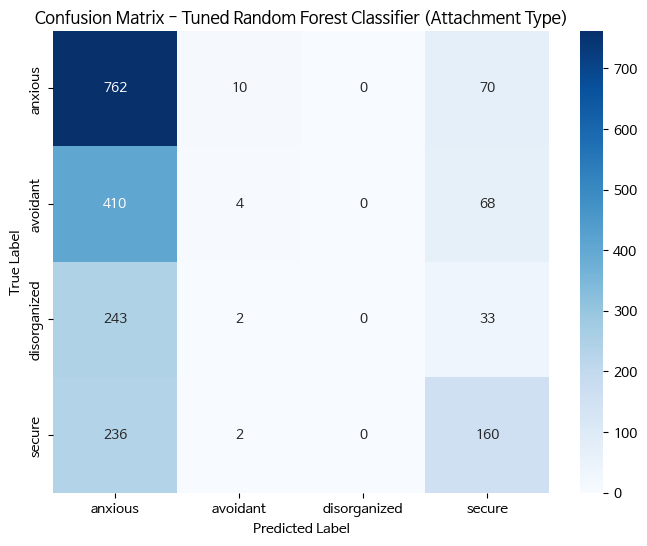

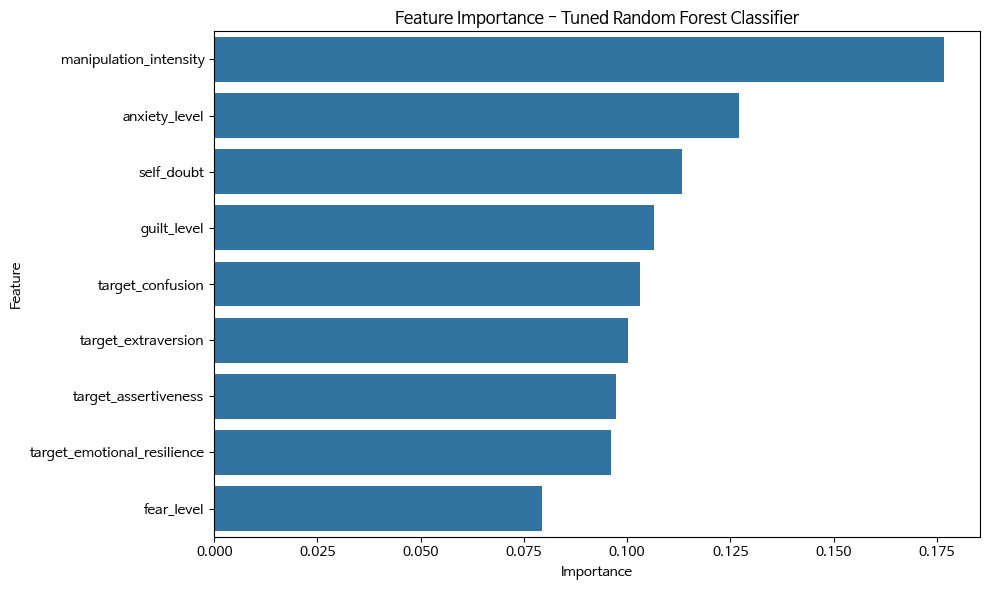

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("튜닝된 랜덤 포레스트 분류기 모델 평가 시작...")

# 튜닝된 모델로 테스트 세트에 대한 예측 수행
tuned_rf_pred_attachment = best_rf_model_attachment.predict(X_test_scaled_attachment)

print("튜닝된 랜덤 포레스트 분류기 예측 완료.")

# 정확도 비교
print("\n튜닝된 Random Forest Classifier Accuracy (Attachment Type):", accuracy_score(y_test_attachment, tuned_rf_pred_attachment))

# 분류 보고서 (Precision, Recall, F1-score)
print("\n--- 튜닝된 랜덤 포레스트 분류기 분류 보고서 (Attachment Type) ---")
print(classification_report(y_test_attachment, tuned_rf_pred_attachment, target_names=le_attachment.classes_))

# 혼동 행렬 시각화
cm_tuned_rf_attachment = confusion_matrix(y_test_attachment, tuned_rf_pred_attachment)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned_rf_attachment, annot=True, fmt='d', cmap='Blues', xticklabels=le_attachment.classes_, yticklabels=le_attachment.classes_)
plt.title("Confusion Matrix - Tuned Random Forest Classifier (Attachment Type)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 특성 중요도 분석 (Feature Importance)
feature_importances = best_rf_model_attachment.feature_importances_
features = X_attachment.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance - Tuned Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### SMOTE 적용을 통한 클래스 불균형 해결

훈련 데이터에 SMOTE (Synthetic Minority Over-sampling Technique)를 적용하여 `manipulation_type` 클래스 간의 불균형을 해결하겠습니다. 이는 소수 클래스에 대한 모델의 예측 능력을 향상시키는 데 목적이 있습니다.

VotingClassifier 모델 평가

훈련된 `VotingClassifier` 모델을 사용하여 테스트 세트에 대한 예측을 수행하고, 모델의 성능을 평가합니다. 다른 개별 모델들과 비교하여 앙상블의 효과를 확인합니다.

VotingClassifier 예측 완료.

VotingClassifier Accuracy (Manipulation Type) with SMOTE: 0.988

--- SMOTE 적용 후 VotingClassifier 분류 보고서 (Manipulation Type) ---
                    precision    recall  f1-score   support

    charm_flattery       1.00      1.00      1.00       280
   direct_coercion       1.00      1.00      1.00       280
       gaslighting       1.00      1.00      1.00       280
    guilt_tripping       1.00      1.00      1.00       280
      love_bombing       0.96      0.96      0.96       280
           neutral       1.00      1.00      1.00       320
passive_aggressive       0.96      0.96      0.96       280

          accuracy                           0.99      2000
         macro avg       0.99      0.99      0.99      2000
      weighted avg       0.99      0.99      0.99      2000



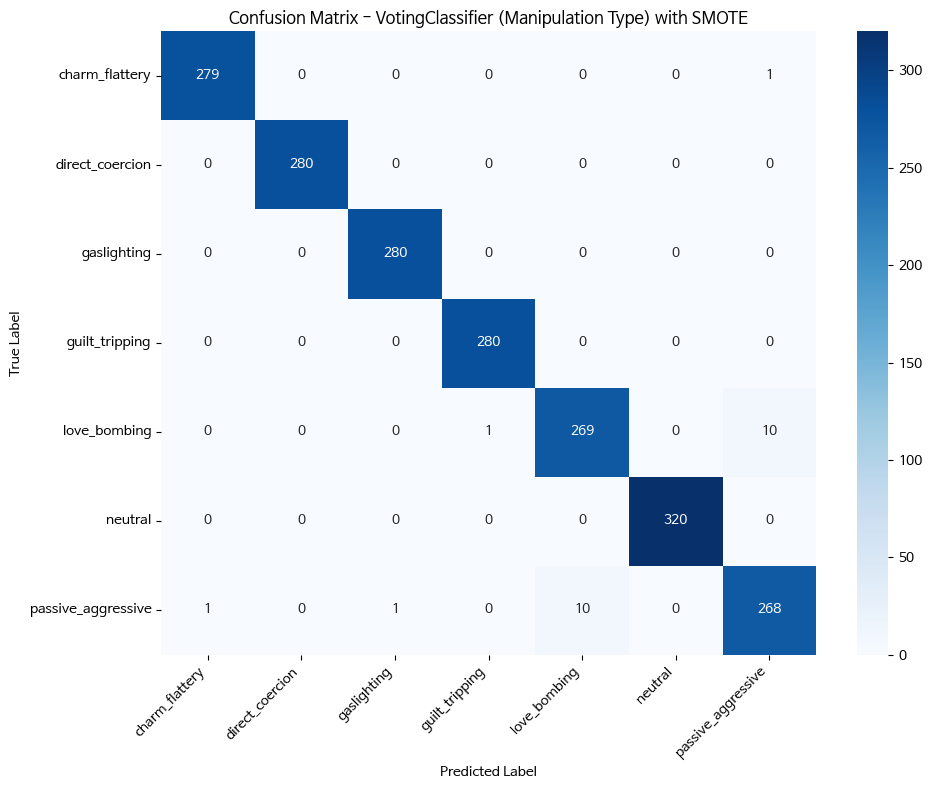

In [82]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 테스트 세트에 대한 예측 (VotingClassifier 모델)
voting_pred_manipulation = voting_clf_manipulation.predict(X_test_scaled_manipulation)

print("VotingClassifier 예측 완료.")

# 정확도 비교
print("\nVotingClassifier Accuracy (Manipulation Type) with SMOTE:", accuracy_score(y_test_manipulation, voting_pred_manipulation))

# 분류 보고서 (Precision, Recall, F1-score)
print("\n--- SMOTE 적용 후 VotingClassifier 분류 보고서 (Manipulation Type) ---")
print(classification_report(y_test_manipulation, voting_pred_manipulation, target_names=le_manipulation.classes_))

# 혼동 행렬 시각화
cm_voting_manipulation = confusion_matrix(y_test_manipulation, voting_pred_manipulation)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_voting_manipulation, annot=True, fmt='d', cmap='Blues', xticklabels=le_manipulation.classes_, yticklabels=le_manipulation.classes_)
plt.title("Confusion Matrix - VotingClassifier (Manipulation Type) with SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###  모델 평가

새로운 피처와 SMOTE가 적용된 데이터로 훈련된 각 모델의 성능을 평가하고, 특히 `manipulation_type` 예측 능력을 확인합니다.

모든 모델 예측 완료.

Logistic Regression Accuracy (Manipulation Type) with SMOTE: 0.9745
Random Forest Classifier Accuracy (Manipulation Type) with SMOTE: 0.9855
XGBoost Classifier Accuracy (Manipulation Type) with SMOTE: 0.9905

--- SMOTE 적용 후 로지스틱 회귀 분류 보고서 (Manipulation Type) ---
                    precision    recall  f1-score   support

    charm_flattery       0.99      0.98      0.98       280
   direct_coercion       1.00      1.00      1.00       280
       gaslighting       0.98      1.00      0.99       280
    guilt_tripping       0.99      1.00      0.99       280
      love_bombing       0.92      0.94      0.93       280
           neutral       1.00      1.00      1.00       320
passive_aggressive       0.93      0.91      0.92       280

          accuracy                           0.97      2000
         macro avg       0.97      0.97      0.97      2000
      weighted avg       0.97      0.97      0.97      2000


--- SMOTE 적용 후 랜덤 포레스트 분류기 분류 보고서 (Manipulation Type) ---
 

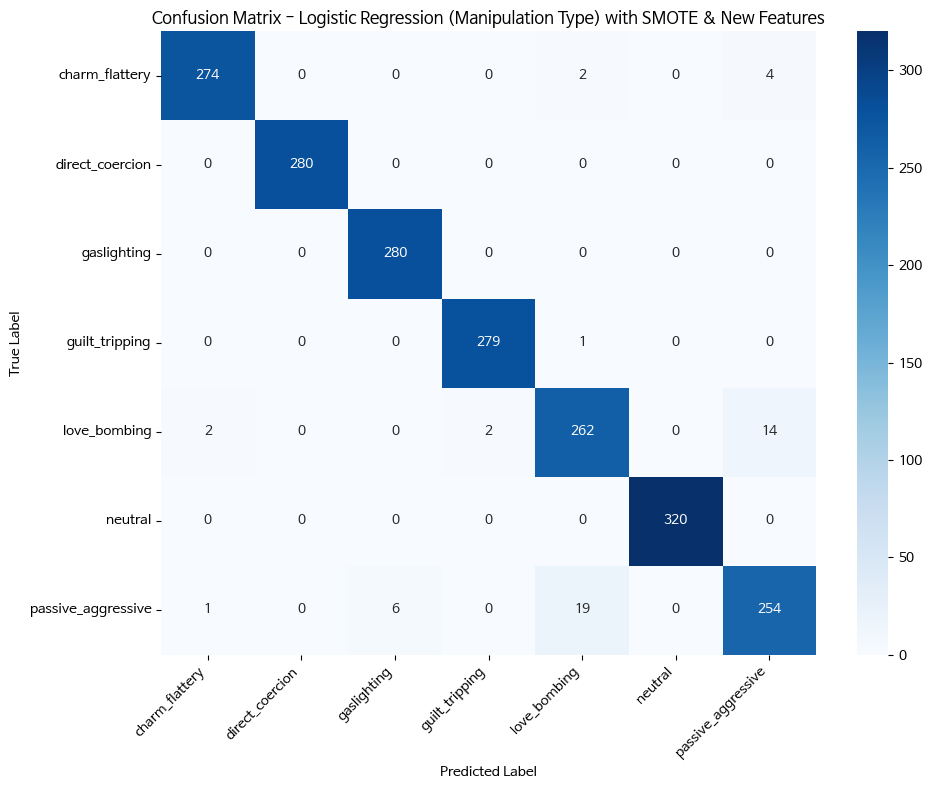

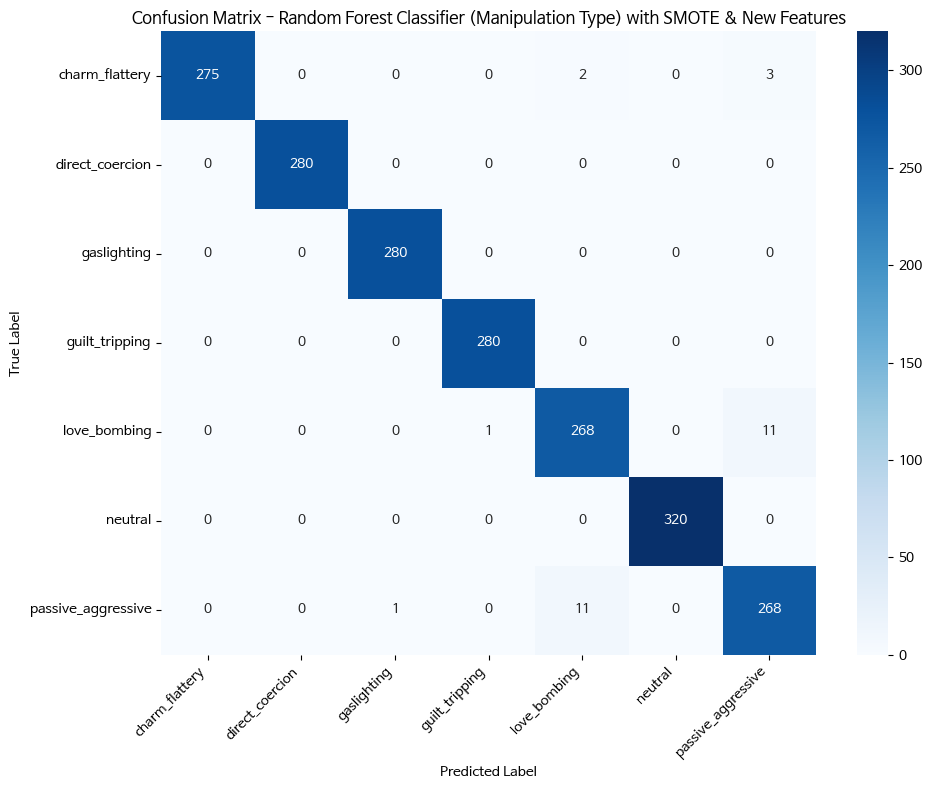

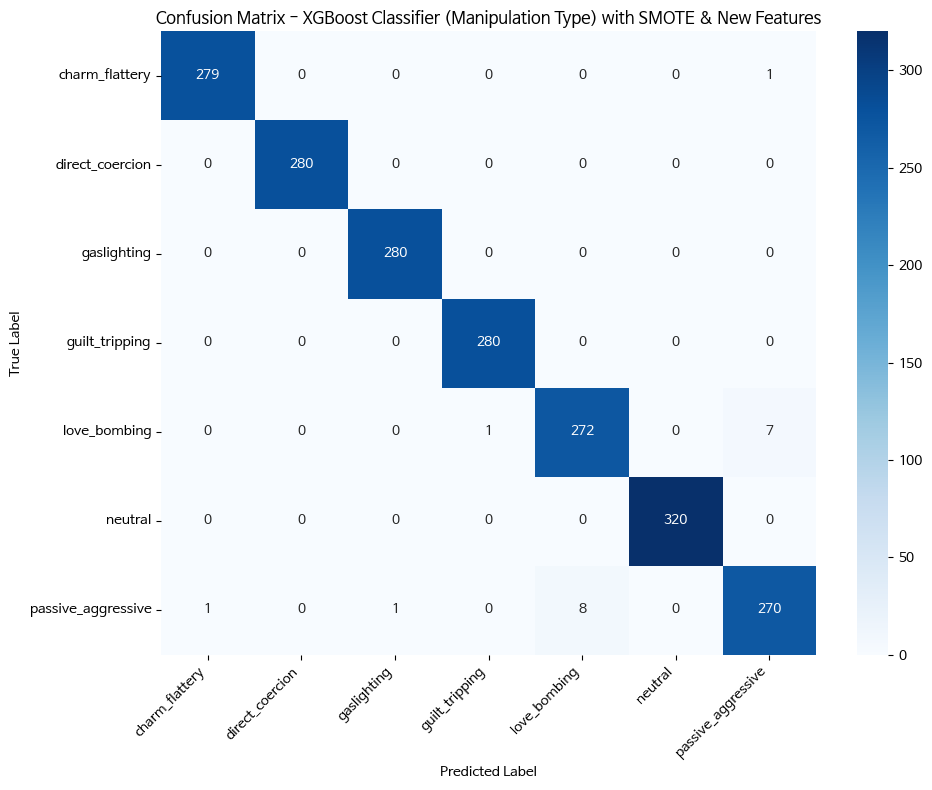

In [81]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 테스트 세트에 대한 예측
log_pred_manipulation = log_model_manipulation.predict(X_test_scaled_manipulation)
rf_pred_manipulation = rf_model_manipulation.predict(X_test_scaled_manipulation)
xgb_pred_manipulation = xgb_model_manipulation.predict(X_test_scaled_manipulation)

print("모든 모델 예측 완료.")

# 정확도 비교
print("\nLogistic Regression Accuracy (Manipulation Type) with SMOTE:", accuracy_score(y_test_manipulation, log_pred_manipulation))
print("Random Forest Classifier Accuracy (Manipulation Type) with SMOTE:", accuracy_score(y_test_manipulation, rf_pred_manipulation))
print("XGBoost Classifier Accuracy (Manipulation Type) with SMOTE:", accuracy_score(y_test_manipulation, xgb_pred_manipulation))

# 분류 보고서 (로지스틱 회귀)
print("\n--- SMOTE 적용 후 로지스틱 회귀 분류 보고서 (Manipulation Type) ---")
print(classification_report(y_test_manipulation, log_pred_manipulation, target_names=le_manipulation.classes_))

# 분류 보고서 (랜덤 포레스트)
print("\n--- SMOTE 적용 후 랜덤 포레스트 분류기 분류 보고서 (Manipulation Type) ---")
print(classification_report(y_test_manipulation, rf_pred_manipulation, target_names=le_manipulation.classes_))

# 분류 보고서 (XGBoost)
print("\n--- SMOTE 적용 후 XGBoost 분류기 분류 보고서 (Manipulation Type) ---")
print(classification_report(y_test_manipulation, xgb_pred_manipulation, target_names=le_manipulation.classes_))

# 로지스틱 회귀 혼동 행렬 시각화
cm_log_manipulation = confusion_matrix(y_test_manipulation, log_pred_manipulation)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_log_manipulation, annot=True, fmt='d', cmap='Blues', xticklabels=le_manipulation.classes_, yticklabels=le_manipulation.classes_)
plt.title("Confusion Matrix - Logistic Regression (Manipulation Type) with SMOTE & New Features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 랜덤 포레스트 분류기 혼동 행렬 시각화
cm_rf_manipulation = confusion_matrix(y_test_manipulation, rf_pred_manipulation)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf_manipulation, annot=True, fmt='d', cmap='Blues', xticklabels=le_manipulation.classes_, yticklabels=le_manipulation.classes_)
plt.title("Confusion Matrix - Random Forest Classifier (Manipulation Type) with SMOTE & New Features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# XGBoost 혼동 행렬 시각화
cm_xgb_manipulation = confusion_matrix(y_test_manipulation, xgb_pred_manipulation)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb_manipulation, annot=True, fmt='d', cmap='Blues', xticklabels=le_manipulation.classes_, yticklabels=le_manipulation.classes_)
plt.title("Confusion Matrix - XGBoost Classifier (Manipulation Type) with SMOTE & New Features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1. 데이터 준비: 특성(X_manipulation)과 목표 변수(y_manipulation) 정의

`manipulation_type`을 예측하기 위한 모델을 구현하기 위해 심리적 지표와 새롭게 생성된 파생 변수들을 특성으로 사용하고, `manipulation_type`을 목표 변수로 정의하겠습니다.

`manipulation_type`은 범주형 데이터이므로, 머신러닝 모델이 이해할 수 있도록 `LabelEncoder`를 사용하여 숫자로 변환해야 합니다.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import time

# 사용할 변수 (특성 - X_manipulation)
# 기존 심리 지표들과 모든 파생 변수를 포함합니다.
features_manipulation = [
    'manipulation_intensity',
    'target_confusion',
    'guilt_level',
    'fear_level',
    'anxiety_level',
    'self_doubt',
    'target_extraversion',
    'target_emotional_resilience',
    'target_assertiveness',
    'psychological_distress_score', # 기존 파생 변수
    'manipulation_impact_ratio',    # 기존 파생 변수
    'manipulation_resilience_interaction', # 새로운 파생 변수
    'manipulation_assertiveness_interaction', # 새로운 파생 변수
    'distress_resilience_interaction', # 새로운 파생 변수
    'distress_assertiveness_interaction' # 새로운 파생 변수
]

X_manipulation = df[features_manipulation]

# 목표 변수 (y_manipulation): 'manipulation_type'
y_manipulation = df['manipulation_type']

# 'manipulation_type'을 숫자로 인코딩
le_manipulation = LabelEncoder()
y_encoded_manipulation = le_manipulation.fit_transform(y_manipulation)

print("특성(X_manipulation) 데이터 형태:", X_manipulation.shape)
print("목표 변수(y_manipulation) 인코딩 후 형태:", y_encoded_manipulation.shape)
print("인코딩된 'manipulation_type' 레이블:", le_manipulation.classes_)

특성(X_manipulation) 데이터 형태: (10000, 15)
목표 변수(y_manipulation) 인코딩 후 형태: (10000,)
인코딩된 'manipulation_type' 레이블: ['charm_flattery' 'direct_coercion' 'gaslighting' 'guilt_tripping'
 'love_bombing' 'neutral' 'passive_aggressive']


### 2. 데이터 전처리: 훈련/테스트 세트 분리 및 스케일링

데이터를 훈련 세트와 테스트 세트로 나누고, `StandardScaler`를 사용하여 특성들을 표준화(스케일링)합니다.

In [ ]:
# 데이터를 훈련 세트와 테스트 세트로 분리
X_train_manipulation, X_test_manipulation, y_train_manipulation, y_test_manipulation = train_test_split(
    X_manipulation, y_encoded_manipulation,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded_manipulation # 클래스 불균형을 고려하여 stratify 적용
)

print("훈련 세트 X_manipulation 형태:", X_train_manipulation.shape)
print("테스트 세트 X_manipulation 형태:", X_test_manipulation.shape)
print("훈련 세트 y_manipulation 형태:", y_train_manipulation.shape)
print("테스트 세트 y_manipulation 형태:", y_test_manipulation.shape)

# 특성 스케일링 (StandardScaler)
scaler_manipulation = StandardScaler()
X_train_scaled_manipulation = scaler_manipulation.fit_transform(X_train_manipulation)
X_test_scaled_manipulation = scaler_manipulation.transform(X_test_manipulation)

print("스케일링된 훈련 세트 X_manipulation 형태:", X_train_scaled_manipulation.shape)
print("스케일링된 테스트 세트 X_manipulation 형태:", X_test_scaled_manipulation.shape)

훈련 세트 X_manipulation 형태: (8000, 15)
테스트 세트 X_manipulation 형태: (2000, 15)
훈련 세트 y_manipulation 형태: (8000,)
테스트 세트 y_manipulation 형태: (2000,)
스케일링된 훈련 세트 X_manipulation 형태: (8000, 15)
스케일링된 테스트 세트 X_manipulation 형태: (2000, 15)


##   피쳐 엔지니어링 (Feature Engineering) - 추가 개선

모델의 성능 향상을 위해 기존에 생성된 파생 변수에 더하여, 심리 조작과 대상의 특성 간의 상호작용을 포착하는 새로운 파생 변수들을 생성합니다. 이는 모델이 복합적인 관계를 학습하고 예측력을 높이는 데 기여할 수 있습니다.

### 모델 선택 및 훈련 (target_attachment_style 예측을 위한 초기 모델)

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import time

# 로지스틱 회귀 모델 훈련
print("로지스틱 회귀 모델 훈련 시작...")
start_log_attachment = time.time()
log_model_attachment = LogisticRegression(max_iter=1000, random_state=42)
log_model_attachment.fit(X_train_scaled_attachment, y_train_attachment)
end_log_attachment = time.time()
print(f"로지스틱 회귀 모델 훈련 시간: {end_log_attachment - start_log_attachment:.4f} 초")

# 랜덤 포레스트 분류기 훈련
print("랜덤 포레스트 분류기 훈련 시작...")
start_rf_attachment = time.time()
rf_model_attachment = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model_attachment.fit(X_train_scaled_attachment, y_train_attachment)
end_rf_attachment = time.time()
print(f"랜덤 포레스트 분류기 훈련 시간: {end_rf_attachment - start_rf_attachment:.4f} 초")

로지스틱 회귀 모델 훈련 시작...
로지스틱 회귀 모델 훈련 시간: 0.2845 초
랜덤 포레스트 분류기 훈련 시작...
랜덤 포레스트 분류기 훈련 시간: 5.3681 초


### SMOTE 적용을 통한 클래스 불균형 해결 (manipulation_type)

In [78]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

print("SMOTE 라이브러리 및 필요한 유틸리티 임포트 완료.")

# 원본 훈련 세트의 클래스 분포 확인
original_counts_manipulation = Counter(y_train_manipulation)
print(f"\nOriginal training set class distribution (manipulation_type): {original_counts_manipulation}")

# 클래스 분포를 기준으로 오버샘플링 전략 정의
# 모든 클래스를 가장 많은 클래스의 샘플 수에 맞춰 오버샘플링합니다.
max_samples = max(original_counts_manipulation.values())

sampling_strategy_manipulation = {}
for class_label, count in original_counts_manipulation.items():
    if count < max_samples:
        sampling_strategy_manipulation[class_label] = max_samples

# SMOTE 인스턴스 생성
sm_manipulation = SMOTE(sampling_strategy=sampling_strategy_manipulation, random_state=42)

# SMOTE 적용
X_resampled_manipulation, y_resampled_manipulation = sm_manipulation.fit_resample(X_train_scaled_manipulation, y_train_manipulation)

print(f"Resampled training set class distribution (manipulation_type): {Counter(y_resampled_manipulation)}")
print("SMOTE applied successfully to training data for manipulation_type.")

SMOTE 라이브러리 및 필요한 유틸리티 임포트 완료.

Original training set class distribution (manipulation_type): Counter({np.int64(5): 1280, np.int64(2): 1120, np.int64(6): 1120, np.int64(3): 1120, np.int64(4): 1120, np.int64(0): 1120, np.int64(1): 1120})
Resampled training set class distribution (manipulation_type): Counter({np.int64(2): 1280, np.int64(6): 1280, np.int64(3): 1280, np.int64(4): 1280, np.int64(5): 1280, np.int64(0): 1280, np.int64(1): 1280})
SMOTE applied successfully to training data for manipulation_type.


# 모델 선택 및 훈련 (manipulation_type)

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 로지스틱 회귀 모델 훈련 (SMOTE 데이터 사용)
print("SMOTE 적용 후 manipulation_type 예측 로지스틱 회귀 모델 훈련 시작...")
start_log_manipulation = time.time()
log_model_manipulation = LogisticRegression(max_iter=1000, random_state=42)
log_model_manipulation.fit(X_resampled_manipulation, y_resampled_manipulation)
end_log_manipulation = time.time()
print(f"SMOTE 적용 후 manipulation_type 예측 로지스틱 회귀 모델 훈련 시간: {end_log_manipulation - start_log_manipulation:.4f} 초")

# 랜덤 포레스트 분류기 훈련 (SMOTE 데이터 사용)
print("SMOTE 적용 후 manipulation_type 예측 랜덤 포레스트 분류기 훈련 시작...")
start_rf_manipulation = time.time()
rf_model_manipulation = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model_manipulation.fit(X_resampled_manipulation, y_resampled_manipulation)
end_rf_manipulation = time.time()
print(f"SMOTE 적용 후 manipulation_type 예측 랜덤 포레스트 분류기 훈련 시간: {end_rf_manipulation - start_rf_manipulation:.4f} 초")

# XGBoost Classifier 모델 훈련 (SMOTE 데이터 사용)
print("XGBoost Classifier 모델 훈련 시작...")
start_xgb_manipulation = time.time()
xgb_model_manipulation = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_manipulation.classes_),
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    random_state=42
)
xgb_model_manipulation.fit(X_resampled_manipulation, y_resampled_manipulation)
end_xgb_manipulation = time.time()
print(f"XGBoost Classifier 모델 훈련 시간: {end_xgb_manipulation - start_xgb_manipulation:.4f} 초")

SMOTE 적용 후 manipulation_type 예측 로지스틱 회귀 모델 훈련 시작...
SMOTE 적용 후 manipulation_type 예측 로지스틱 회귀 모델 훈련 시간: 0.2245 초
SMOTE 적용 후 manipulation_type 예측 랜덤 포레스트 분류기 훈련 시작...
SMOTE 적용 후 manipulation_type 예측 랜덤 포레스트 분류기 훈련 시간: 4.9419 초
XGBoost Classifier 모델 훈련 시작...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:15:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier 모델 훈련 시간: 5.0561 초


### 앙상블 기법 적용 - VotingClassifier (manipulation_type)

In [80]:
from sklearn.ensemble import VotingClassifier

print("VotingClassifier 모델 훈련 시작...")
start_voting_manipulation = time.time()

# 개별 모델 정의 (SMOTE 데이터로 훈련된 모델들)
estimators = [
    ('logistic', log_model_manipulation),
    ('random_forest', rf_model_manipulation),
    ('xgboost', xgb_model_manipulation)
]

# VotingClassifier 초기화 및 훈련 (소프트 보팅 사용 - 확률 예측을 평균)
voting_clf_manipulation = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1, weights=[1, 1, 1])

# VotingClassifier 훈련
voting_clf_manipulation.fit(X_resampled_manipulation, y_resampled_manipulation)

end_voting_manipulation = time.time()
print(f"VotingClassifier 모델 훈련 시간: {end_voting_manipulation - start_voting_manipulation:.4f} 초")

VotingClassifier 모델 훈련 시작...
VotingClassifier 모델 훈련 시간: 8.8112 초


In [ ]:
# 새로운 상호작용 파생 변수 생성
# 1. 조작 강도와 회복 탄력성 상호작용
df['manipulation_resilience_interaction'] = df['manipulation_intensity'] * df['target_emotional_resilience']

# 2. 조작 강도와 자기주장성 상호작용
df['manipulation_assertiveness_interaction'] = df['manipulation_intensity'] * df['target_assertiveness']

# 3. 심리적 고통 지수와 회복 탄력성 상호작용
df['distress_resilience_interaction'] = df['psychological_distress_score'] * df['target_emotional_resilience']

# 4. 심리적 고통 지수와 자기주장성 상호작용
df['distress_assertiveness_interaction'] = df['psychological_distress_score'] * df['target_assertiveness']

print("새로운 상호작용 파생 변수 생성 후 DataFrame head:")
display(df[[
    'manipulation_intensity',
    'target_emotional_resilience',
    'target_assertiveness',
    'psychological_distress_score',
    'manipulation_resilience_interaction',
    'manipulation_assertiveness_interaction',
    'distress_resilience_interaction',
    'distress_assertiveness_interaction'
]].head())

새로운 상호작용 파생 변수 생성 후 DataFrame head:


,manipulation_intensity,target_emotional_resilience,target_assertiveness,psychological_distress_score,manipulation_resilience_interaction,manipulation_assertiveness_interaction,distress_resilience_interaction,distress_assertiveness_interaction
0,0.705,0.101,0.222,0.3122,0.071205,0.156510,0.031532,0.069308
1,0.530,0.380,0.342,0.2320,0.201400,0.181260,0.088160,0.079344
2,0.651,0.064,0.201,0.4494,0.041664,0.130851,0.028762,0.090329
3,0.673,0.168,0.422,0.4954,0.113064,0.284006,0.083227,0.209059
4,0.331,0.331,0.787,0.3514,0.109561,0.260497,0.116313,0.276552
